In [2]:
# file_path = '/content/drive/My Drive/Master Thesis/stock_return_data.xlsx'
# df = pd.read_excel(file_path)

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import matplotlib.dates as mdates
from sklearn import datasets, linear_model
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import statsmodels.api as sm
from scipy.stats import t
from scipy.optimize import minimize
import os
import cvxpy as cp
from tqdm import tqdm
import seaborn as sns
import torch

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import openpyxl

# Try to train a first model with torch and custom loss function (later SPO+ loss)

In [107]:
data_path = "../data/processed/"

return_data = pd.read_csv(data_path + "stationary_return_data_subset.csv")

In [108]:
return_data

,RIC,date,return
0,CTRA.N,2000-01-31,-0.081712
1,CTRA.N,2000-02-29,0.074857
2,CTRA.N,2000-03-31,0.142292
3,CTRA.N,2000-04-28,0.027682
4,CTRA.N,2000-05-31,0.345877
...,...,...,...
2885,TYL.N,2023-09-29,-0.030846
2886,TYL.N,2023-10-31,-0.034288
2887,TYL.N,2023-11-30,0.096380
2888,TYL.N,2023-12-29,0.022698


In [109]:
return_data.groupby("RIC").describe()

return                                                              \
         count      mean       std       min       25%       50%       75%   
RIC                                                                          
BRO.N    289.0  0.015256  0.068269 -0.205521 -0.030288  0.011805  0.052854   
CTRA.N   289.0  0.017228  0.110793 -0.350214 -0.053785  0.016744  0.076084   
CVS.N    289.0  0.009454  0.076215 -0.296903 -0.040299  0.004855  0.059982   
FFIV.OQ  289.0  0.018358  0.168274 -0.618090 -0.059265  0.009869  0.087350   
HSY.N    289.0  0.010781  0.057591 -0.180858 -0.025007  0.008270  0.042192   
LLY.N    289.0  0.012871  0.072310 -0.294859 -0.025332  0.008069  0.049580   
NEM.N    289.0  0.007799  0.103439 -0.320433 -0.057108  0.000390  0.074414   
PCG.N    289.0  0.007660  0.110044 -0.452632 -0.022140  0.011364  0.050132   
REGN.OQ  289.0  0.034462  0.266126 -0.589967 -0.069364  0.002883  0.100396   
TYL.N    289.0  0.020709  0.108711 -0.359375 -0.041102  0.013012  0.078528   

                   
              max  
RIC                
BRO.N    0.272894  
CTRA.N   0.569182  
CVS.N    0.322382  
FFIV.OQ  0.789474  
HSY.N    0.267936  
LLY.N    0.311987  
NEM.N    0.330688  
PCG.N    0.457105  
REGN.OQ  3.588832  
TYL.N    0.703226

In [110]:
# Pivot return data
return_matrix = return_data.pivot(index='date', columns='RIC', values='return')
display(return_matrix)

RIC,BRO.N,CTRA.N,CVS.N,FFIV.OQ,HSY.N,LLY.N,NEM.N,PCG.N,REGN.OQ,TYL.N
date,,,,,,,,,,
2000-01-31,-0.104405,-0.081712,-1.236885e-01,-0.175439,-0.105263,0.005639,-0.168367,7.012195e-02,-0.034314,-0.204545
2000-02-29,-0.035086,0.074857,1.788909e-03,-0.042553,0.039651,-0.107465,0.085890,-5.982906e-02,3.588832,0.228571
2000-03-31,0.172348,0.142292,7.321429e-02,-0.247222,0.109531,0.059937,0.015535,3.281437e-02,-0.476770,0.104651
2000-04-28,0.037157,0.027682,1.595897e-01,-0.310886,-0.069231,0.227183,0.044568,2.351190e-01,-0.033827,-0.094737
2000-05-31,0.165747,0.345877,1.398903e-11,-0.309237,0.148974,-0.011941,-0.016000,1.444134e-11,-0.286652,-0.255814
...,...,...,...,...,...,...,...,...,...,...
2023-09-29,-0.057490,-0.040440,7.135185e-02,-0.015398,-0.068789,-0.030801,-0.052920,-1.042945e-02,-0.004271,-0.030846
2023-10-31,-0.004152,0.016636,-3.132471e-03,-0.059265,-0.063625,0.031277,0.014073,1.053937e-02,-0.052335,-0.034288
2023-11-30,0.076635,-0.038423,-1.536009e-02,0.129296,0.009148,0.068968,0.083216,5.337423e-02,0.056316,0.096380


In [111]:
# Perform bootstrap
return_array = return_matrix.values

# Number of bootstrap scenarios
num_scenarios = 1000

# Set random seed for reproducibility
np.random.seed(42)

# Sample row indices with replacement
sample_indices = np.random.choice(return_array.shape[0], size=num_scenarios, replace=True)

# Generate bootstrapped scenario matrix
scenario_matrix = return_array[sample_indices, :]

loss_matrix = -scenario_matrix

print(scenario_matrix.shape)

(1000, 10)


In [112]:
# scenario_matrix (S scenarios × N assets)
S, N = scenario_matrix.shape

# Empirical mean from scenarios
mu = scenario_matrix.mean(axis=0)

print(S, N)

1000 10


In [113]:
# Set CVar
alpha = 0.9

def compute_cvar(portfolio_losses, alpha=0.95):
    sorted_losses = np.sort(portfolio_losses)
    k = int(np.ceil(alpha * len(sorted_losses)))
    return sorted_losses[k:].mean()

In [114]:
w = cp.Variable(N)
z = cp.Variable(S)
h = cp.Variable()

cvar_expr = h + (1 / ((1 - alpha) * S)) * cp.sum(z)        # CVaRα(w)

base_constraints = [
    cp.sum(w) == 1,                 # full investment
    w >= 0,
    w <= 0.20,
    z >= 0,
    z >= loss_matrix @ w - h        # z_s ≥ L_s(w) - h
]

prob_min = cp.Problem(cp.Minimize(cvar_expr), base_constraints)
beta_min = prob_min.solve(solver=cp.HIGHS, warm_start=True)

w_max = cp.Variable(N)
prob_max = cp.Problem(cp.Maximize(mu @ w_max),
                      [cp.sum(w_max)==1, w_max>=0, w_max<=0.20])
prob_max.solve()
beta_max = compute_cvar(loss_matrix @ w_max.value, alpha)

print(f"β_min  = {beta_min : .6f}")
print(f"β_max  = {beta_max : .6f}")

β_min  =  0.047536
β_max  =  0.097340


In [115]:
return_matrix

RIC,BRO.N,CTRA.N,CVS.N,FFIV.OQ,HSY.N,LLY.N,NEM.N,PCG.N,REGN.OQ,TYL.N
date,,,,,,,,,,
2000-01-31,-0.104405,-0.081712,-1.236885e-01,-0.175439,-0.105263,0.005639,-0.168367,7.012195e-02,-0.034314,-0.204545
2000-02-29,-0.035086,0.074857,1.788909e-03,-0.042553,0.039651,-0.107465,0.085890,-5.982906e-02,3.588832,0.228571
2000-03-31,0.172348,0.142292,7.321429e-02,-0.247222,0.109531,0.059937,0.015535,3.281437e-02,-0.476770,0.104651
2000-04-28,0.037157,0.027682,1.595897e-01,-0.310886,-0.069231,0.227183,0.044568,2.351190e-01,-0.033827,-0.094737
2000-05-31,0.165747,0.345877,1.398903e-11,-0.309237,0.148974,-0.011941,-0.016000,1.444134e-11,-0.286652,-0.255814
...,...,...,...,...,...,...,...,...,...,...
2023-09-29,-0.057490,-0.040440,7.135185e-02,-0.015398,-0.068789,-0.030801,-0.052920,-1.042945e-02,-0.004271,-0.030846
2023-10-31,-0.004152,0.016636,-3.132471e-03,-0.059265,-0.063625,0.031277,0.014073,1.053937e-02,-0.052335,-0.034288
2023-11-30,0.076635,-0.038423,-1.536009e-02,0.129296,0.009148,0.068968,0.083216,5.337423e-02,0.056316,0.096380


## Teste ob sich portfolio weights mit unterschiedlichem CVaR tatsächlich ändern

In [120]:
cvar_portfolio_cvars   = []   # x-axis  (CVaR, in %)
cvar_portfolio_returns = []   # y-axis  (E[return], in %)
cvar_weights_list      = []   # store optimal weights
cvar_constraints       = []   # the β that was imposed (in %)

beta_grid = np.linspace(beta_min, beta_max, 100)


w = cp.Variable(N)
z = cp.Variable(S)
h = cp.Variable()
beta_par = cp.Parameter(nonneg=True)

losses = loss_matrix @ w
constraints = [
    cp.sum(w) == 1,
    w >= 0,            # long only
    w <= 0.20,         # 20 % box
    z >= 0,
    z >= losses - h,
    h + (1/((1-alpha)*S))*cp.sum(z) <= beta_par
]
prob = cp.Problem(cp.Maximize(mu @ w), constraints)

for beta in tqdm(beta_grid, desc="CVaR portfolios"):
    beta_par.value = beta
    prob.solve(solver=cp.HIGHS, warm_start=True)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        continue      # skip infeasible

    weights          = w.value
    portfolio_cvar   = compute_cvar(loss_matrix @ weights, alpha)
    portfolio_return = mu @ weights                              

    
    cvar_portfolio_cvars.append(portfolio_cvar * 100)
    cvar_portfolio_returns.append(portfolio_return * 100)
    cvar_weights_list.append(weights)
    cvar_constraints.append(beta * 100)

CVaR portfolios:   0%|          | 0/100 [00:00<?, ?it/s]

CVaR portfolios: 100%|██████████| 100/100 [00:04<00:00, 21.16it/s]


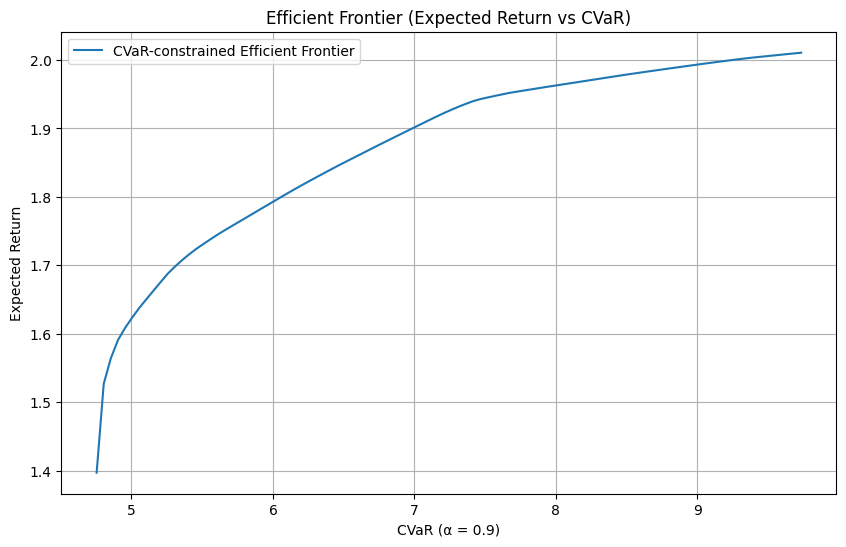

In [121]:
# Plot: x-axis = CVaR, y-axis = expected return
plt.figure(figsize=(10, 6))
plt.plot(cvar_portfolio_cvars, cvar_portfolio_returns, label='CVaR-constrained Efficient Frontier', marker='')
plt.xlabel(f'CVaR (α = {alpha})')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier (Expected Return vs CVaR)')
plt.grid(True)
plt.legend()
# plt.savefig('CVaR_constrained_EF_CVaR.svg', format='svg')
plt.show()

In [122]:
cvar_weights_list

[array([ 0.1830542 ,  0.05212082, -0.        ,  0.02111406,  0.19685432,
         0.16271349,  0.08935922,  0.09600039,  0.03708002,  0.16170347]),
 array([0.2       , 0.05890366, 0.01242993, 0.03592966, 0.2       ,
        0.1536385 , 0.04035029, 0.05740915, 0.04618855, 0.19515025]),
 array([ 0.2       ,  0.0777424 , -0.        ,  0.03640752,  0.2       ,
         0.17319648,  0.02678069,  0.04894552,  0.05189818,  0.18502922]),
 array([ 0.2       ,  0.09693031, -0.        ,  0.03494612,  0.2       ,
         0.17645212,  0.0158036 ,  0.04062244,  0.05323098,  0.18201444]),
 array([ 0.2       ,  0.10675113, -0.        ,  0.03422821,  0.2       ,
         0.1812757 ,  0.00668756,  0.03686068,  0.05521213,  0.17898459]),
 array([ 0.2       ,  0.11688386, -0.        ,  0.03319571,  0.2       ,
         0.18474616,  0.00144279,  0.03126156,  0.05655306,  0.17591685]),
 array([ 0.2       ,  0.12074679, -0.        ,  0.03178058,  0.2       ,
         0.19508025, -0.        ,  0.02181418,  0

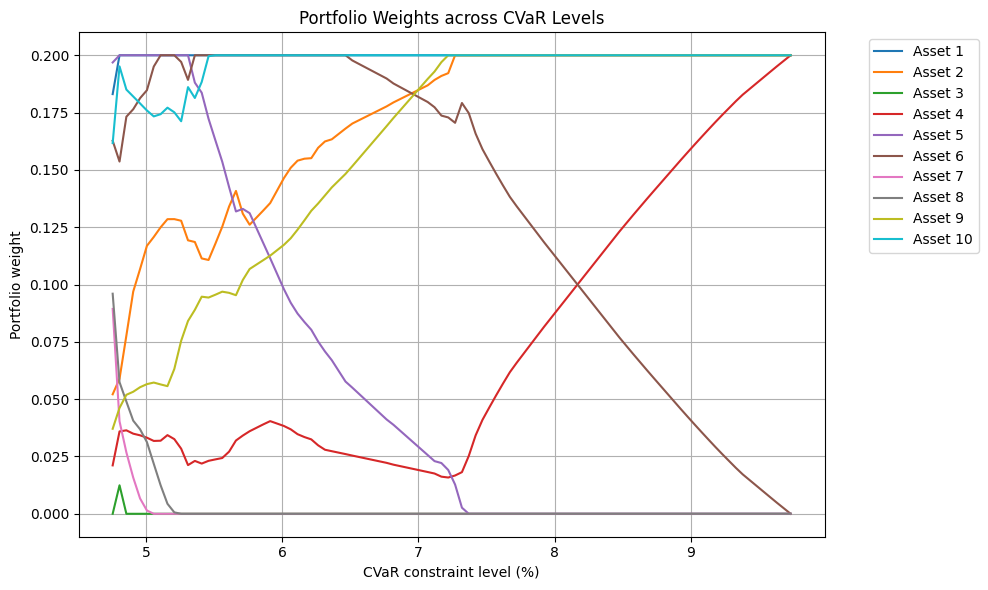

In [126]:
# shape: (n_cvar_levels, n_assets)
weights = np.array(cvar_weights_list)

n_portfolios, n_assets = weights.shape

plt.figure(figsize=(10,6))

for asset in range(n_assets):
    plt.plot(
        # range(n_portfolios),
        cvar_portfolio_cvars,
        weights[:, asset],
        label=f"Asset {asset+1}"
    )

plt.xlabel("CVaR constraint level (%)")
plt.ylabel("Portfolio weight")
plt.title("Portfolio Weights across CVaR Levels")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid()
plt.tight_layout()

plt.show()

## Baue Datensatz für MLP das returns aus letzten 5 lags predicted

was will ich für daten??

Beispiel für EIN Trainingssample (1 prediction):

Input: return distributions of last 3 months

lag3 lag2 lag1

r1   r1   r1

r2   r2   r2

...  ...  ...

r352 r352 r352

Output: return distribution now (predicted or known for training)

r1

r2

...

r352

Abstrahiere auf Trainingsdatensatz:

in X muss in jede Zeile eine Matrix mit so vielen Zeilen wie stocks und Spalten wie lags.

in Y muss in jede Zeile ein Vektor mit so vielen Zeilen wie stocks

In [116]:
return_matrix

RIC,BRO.N,CTRA.N,CVS.N,FFIV.OQ,HSY.N,LLY.N,NEM.N,PCG.N,REGN.OQ,TYL.N
date,,,,,,,,,,
2000-01-31,-0.104405,-0.081712,-1.236885e-01,-0.175439,-0.105263,0.005639,-0.168367,7.012195e-02,-0.034314,-0.204545
2000-02-29,-0.035086,0.074857,1.788909e-03,-0.042553,0.039651,-0.107465,0.085890,-5.982906e-02,3.588832,0.228571
2000-03-31,0.172348,0.142292,7.321429e-02,-0.247222,0.109531,0.059937,0.015535,3.281437e-02,-0.476770,0.104651
2000-04-28,0.037157,0.027682,1.595897e-01,-0.310886,-0.069231,0.227183,0.044568,2.351190e-01,-0.033827,-0.094737
2000-05-31,0.165747,0.345877,1.398903e-11,-0.309237,0.148974,-0.011941,-0.016000,1.444134e-11,-0.286652,-0.255814
...,...,...,...,...,...,...,...,...,...,...
2023-09-29,-0.057490,-0.040440,7.135185e-02,-0.015398,-0.068789,-0.030801,-0.052920,-1.042945e-02,-0.004271,-0.030846
2023-10-31,-0.004152,0.016636,-3.132471e-03,-0.059265,-0.063625,0.031277,0.014073,1.053937e-02,-0.052335,-0.034288
2023-11-30,0.076635,-0.038423,-1.536009e-02,0.129296,0.009148,0.068968,0.083216,5.337423e-02,0.056316,0.096380


In [ ]:
X = []
Y = []

max_lag = 5
n_rows = len(return_matrix)

n = max_lag
while n < n_rows:
    # Get X
    X_row = (return_matrix[n - max_lag:n]).values.flatten()
    X.append(X_row)

    # Get Y
    Y_row = (return_matrix.iloc[n]).values.flatten()
    Y.append(Y_row)
    n = n + 1

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(284, 1760)
(284, 352)


In [49]:
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]

Y_train = Y[:train_size]
Y_test = Y[train_size:]

In [50]:
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_test = y_scaler.transform(Y_test)

In [51]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

In [68]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

batch_size = 16

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [57]:
X_train[0].shape

(1760,)

In [76]:
class ReturnMLP(nn.Module):

    def __init__(self, input_dim, output_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            # nn.Dropout(0.1),

            nn.Linear(1024, 512),
            nn.ReLU(),
            # nn.Dropout(0.1),

            nn.Linear(512, 256),
            nn.ReLU(),
            # nn.Dropout(0.1),

            nn.Linear(256, output_dim)
        )

    def forward(self, x):

        return self.network(x)

In [77]:
input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

model = ReturnMLP(input_dim, output_dim)

print(model)

ReturnMLP(
  (network): Sequential(
    (0): Linear(in_features=1760, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=352, bias=True)
  )
)


In [78]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [79]:
n_epochs = 50

for epoch in range(n_epochs):

    model.train()

    epoch_loss = 0

    for X_batch, Y_batch in train_loader:

        # forward
        predictions = model(X_batch)

        loss = criterion(predictions, Y_batch)

        # backward
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(f"Epoch {epoch+1}: {avg_loss:.6f}")

Epoch 1: 1.002022
Epoch 2: 0.970499
Epoch 3: 0.927328
Epoch 4: 0.812790
Epoch 5: 0.792808
Epoch 6: 0.712266
Epoch 7: 0.695290
Epoch 8: 0.646166
Epoch 9: 0.587888
Epoch 10: 0.559103
Epoch 11: 0.519609
Epoch 12: 0.510336
Epoch 13: 0.470923
Epoch 14: 0.428622
Epoch 15: 0.400709
Epoch 16: 0.363931
Epoch 17: 0.350234
Epoch 18: 0.422822
Epoch 19: 0.354751
Epoch 20: 0.327893
Epoch 21: 0.318744
Epoch 22: 0.292754
Epoch 23: 0.293685
Epoch 24: 0.271736
Epoch 25: 0.260994
Epoch 26: 0.309131
Epoch 27: 0.254929
Epoch 28: 0.231055
Epoch 29: 0.226492
Epoch 30: 0.220847
Epoch 31: 0.212213
Epoch 32: 0.195718
Epoch 33: 0.191808
Epoch 34: 0.194410
Epoch 35: 0.184143
Epoch 36: 0.187117
Epoch 37: 0.183517
Epoch 38: 0.160106
Epoch 39: 0.181296
Epoch 40: 0.158788
Epoch 41: 0.173919
Epoch 42: 0.169142
Epoch 43: 0.168120
Epoch 44: 0.157781
Epoch 45: 0.143380
Epoch 46: 0.145824
Epoch 47: 0.139320
Epoch 48: 0.158280
Epoch 49: 0.155664
Epoch 50: 0.146665


In [80]:
model.eval()

with torch.no_grad():

    preds_scaled = model(X_test_tensor).numpy()

preds = y_scaler.inverse_transform(preds_scaled)

In [81]:
preds = y_scaler.inverse_transform(preds_scaled)
Y_true = y_scaler.inverse_transform(Y_test_tensor.numpy())

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(Y_true, preds)
mae = mean_absolute_error(Y_true, preds)
r2  = r2_score(Y_true, preds)

print("GLOBAL STATS")
print("MSE:", mse)
print("MAE:", mae)
print("R2 :", r2)

GLOBAL STATS
MSE: 0.010344273410737514
MAE: 0.07487663626670837
R2 : -0.18001104891300201


In [67]:
asset_mse = np.mean((Y_true - preds)**2, axis=0)
asset_mae = np.mean(np.abs(Y_true - preds), axis=0)

best_assets = np.argsort(asset_mse)[:10]
worst_assets = np.argsort(asset_mse)[-10:]

print("Best 10 assets (lowest MSE):", best_assets)
print("Worst 10 assets (highest MSE):", worst_assets)

Best 10 assets (lowest MSE): [246  68 179 139 182 248  80 188 287 157]
Worst 10 assets (highest MSE): [241 145  40 240 266 103  62 116 216  27]
